In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score)
from sklearn.model_selection import cross_val_score
import time
import warnings
warnings.filterwarnings('ignore')

# Load prepared data
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')

y_train_multi = y_train['y_train'].values
y_test_multi = y_test['y_test'].values
y_train_bin = y_train['y_train_binary'].values
y_test_bin = y_test['y_test_binary'].values

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Classes: {np.unique(y_train_multi)}')
print('✅ Data loaded!')

X_train: (125973, 26)
X_test:  (22544, 26)
Classes: [0 1 2 3 4]
✅ Data loaded!


In [2]:
# Store all results
results = []

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train, predict, and evaluate a model"""
    print(f'\n{"="*50}')
    print(f'🔧 Training: {name}')
    print(f'{"="*50}')
    
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start
    
    start = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - start
    
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    
    results.append({
        'Model': name,
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2),
        'Train Time (s)': round(train_time, 2),
        'Predict Time (s)': round(pred_time, 3)
    })
    
    print(f'✅ Accuracy:  {acc*100:.2f}%')
    print(f'   Precision: {prec*100:.2f}%')
    print(f'   Recall:    {rec*100:.2f}%')
    print(f'   F1-Score:  {f1*100:.2f}%')
    print(f'   Train time: {train_time:.2f}s')
    
    return model, y_pred

print('✅ Evaluation function ready!')

✅ Evaluation function ready!


In [3]:
dt_model, dt_pred = evaluate_model(
    'Decision Tree',
    DecisionTreeClassifier(random_state=42, max_depth=20),
    X_train, X_test, y_train_multi, y_test_multi
)


🔧 Training: Decision Tree
✅ Accuracy:  74.05%
   Precision: 68.75%
   Recall:    74.05%
   F1-Score:  69.83%
   Train time: 0.65s


In [4]:
rf_model, rf_pred = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, X_test, y_train_multi, y_test_multi
)


🔧 Training: Random Forest
✅ Accuracy:  76.11%
   Precision: 82.18%
   Recall:    76.11%
   F1-Score:  71.86%
   Train time: 2.60s


In [5]:
xgb_model, xgb_pred = evaluate_model(
    'XGBoost',
    XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.1,
                  random_state=42, use_label_encoder=False,
                  eval_metric='mlogloss', verbosity=0),
    X_train, X_test, y_train_multi, y_test_multi
)


🔧 Training: XGBoost
✅ Accuracy:  75.20%
   Precision: 81.29%
   Recall:    75.20%
   F1-Score:  70.85%
   Train time: 2.86s


In [6]:
knn_model, knn_pred = evaluate_model(
    'KNN (K=5)',
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    X_train, X_test, y_train_multi, y_test_multi
)


🔧 Training: KNN (K=5)
✅ Accuracy:  76.18%
   Precision: 80.54%
   Recall:    76.18%
   F1-Score:  72.38%
   Train time: 0.05s


In [7]:
lr_model, lr_pred = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    X_train, X_test, y_train_multi, y_test_multi
)


🔧 Training: Logistic Regression
✅ Accuracy:  73.37%
   Precision: 73.97%
   Recall:    73.37%
   F1-Score:  68.63%
   Train time: 3.96s


In [8]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

print('🏆 MODEL COMPARISON TABLE')
print('=' * 80)
print(results_df.to_string(index=False))

# Highlight best model
best = results_df.iloc[0]
print(f'\n🥇 BEST MODEL: {best["Model"]} with {best["F1-Score"]}% F1-Score')

🏆 MODEL COMPARISON TABLE
              Model  Accuracy  Precision  Recall  F1-Score  Train Time (s)  Predict Time (s)
          KNN (K=5)     76.18      80.54   76.18     72.38            0.05             4.276
      Random Forest     76.11      82.18   76.11     71.86            2.60             0.039
            XGBoost     75.20      81.29   75.20     70.85            2.86             0.056
      Decision Tree     74.05      68.75   74.05     69.83            0.65             0.005
Logistic Regression     73.37      73.97   73.37     68.63            3.96             0.000

🥇 BEST MODEL: KNN (K=5) with 72.38% F1-Score


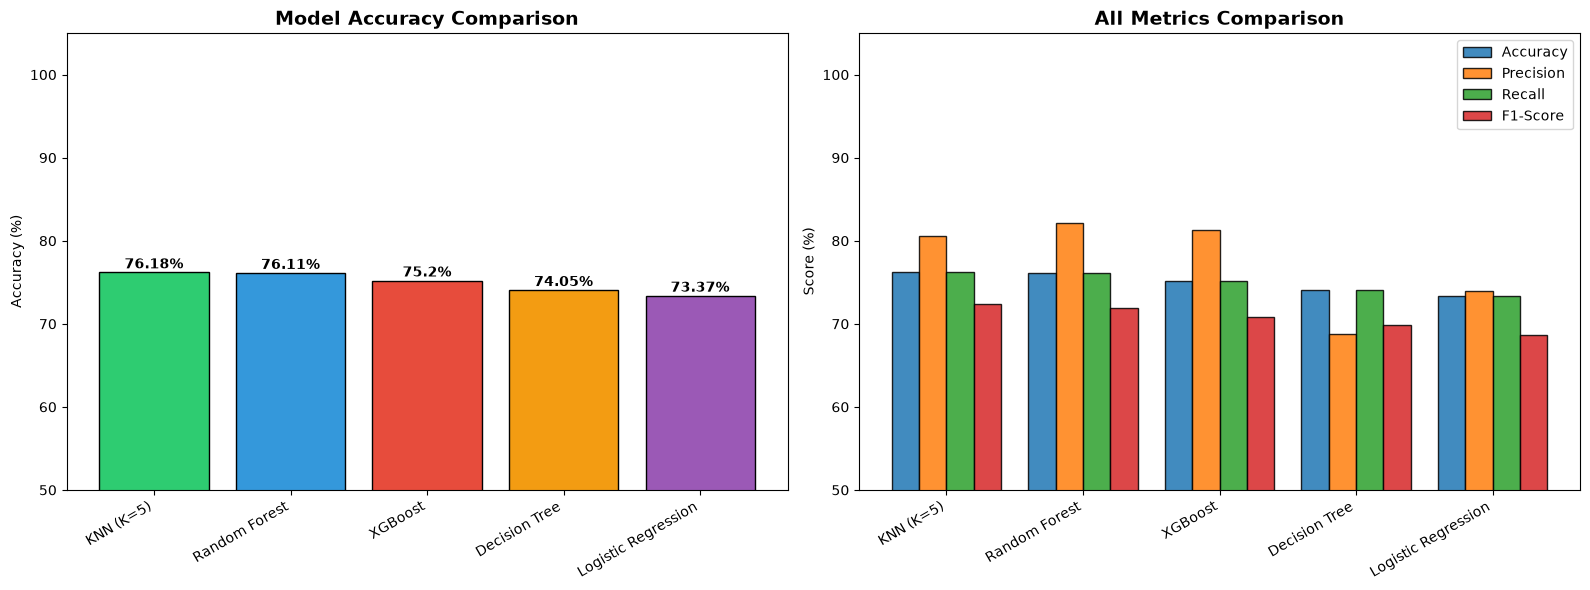

📊 Chart saved to reports/model_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy comparison
models = results_df['Model']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
x = range(len(models))

bars = axes[0].bar(x, results_df['Accuracy'], color=colors[:len(models)], edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=30, ha='right')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison', fontweight='bold', fontsize=14)
axes[0].set_ylim(50, 105)
for bar, val in zip(bars, results_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val}%', ha='center', fontweight='bold')

# Plot 2: All metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x_pos = np.arange(len(models))
width = 0.2
for i, metric in enumerate(metrics):
    axes[1].bar(x_pos + i*width, results_df[metric], width,
                label=metric, edgecolor='black', alpha=0.85)
axes[1].set_xticks(x_pos + width*1.5)
axes[1].set_xticklabels(models, rotation=30, ha='right')
axes[1].set_ylabel('Score (%)')
axes[1].set_title('All Metrics Comparison', fontweight='bold', fontsize=14)
axes[1].legend()
axes[1].set_ylim(50, 105)

plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved to reports/model_comparison.png')

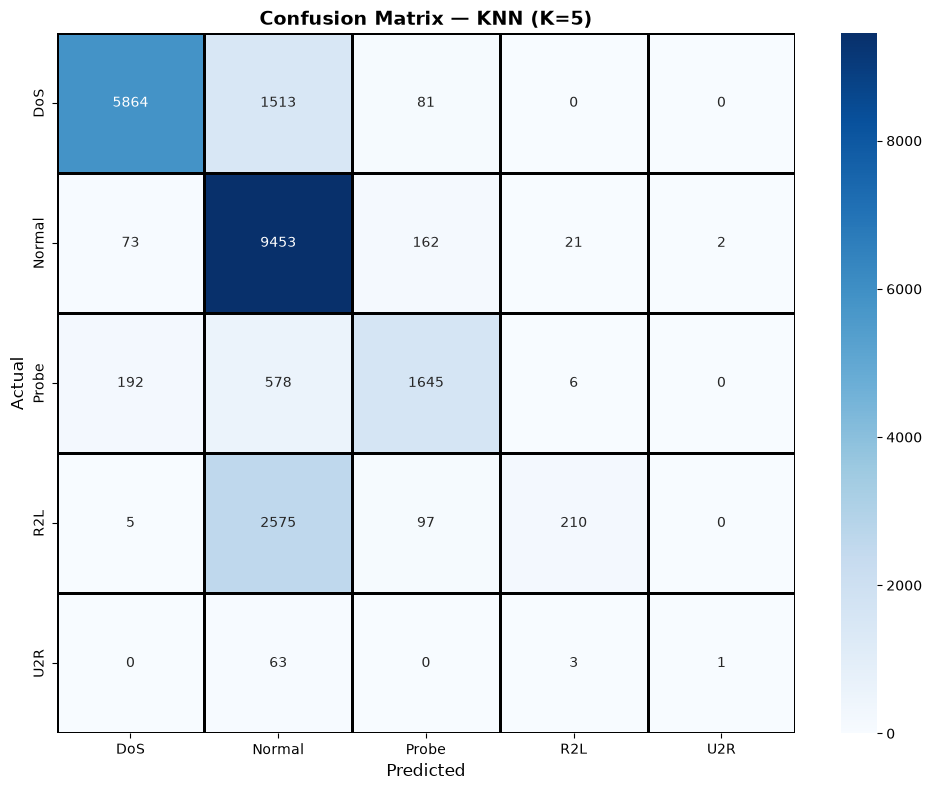


=== Classification Report — KNN (K=5) ===
              precision    recall  f1-score   support

         DoS       0.96      0.79      0.86      7458
      Normal       0.67      0.97      0.79      9711
       Probe       0.83      0.68      0.75      2421
         R2L       0.88      0.07      0.13      2887
         U2R       0.33      0.01      0.03        67

    accuracy                           0.76     22544
   macro avg       0.73      0.51      0.51     22544
weighted avg       0.81      0.76      0.72     22544



In [10]:
# Use the best model's predictions (update variable if needed)
best_name = results_df.iloc[0]['Model']
best_preds = {'Decision Tree': dt_pred, 'Random Forest': rf_pred,
              'XGBoost': xgb_pred, 'KNN (K=5)': knn_pred,
              'Logistic Regression': lr_pred}

y_pred_best = best_preds[best_name]
cm = confusion_matrix(y_test_multi, y_pred_best)
labels = ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
            yticklabels=labels, ax=ax, linewidths=1, linecolor='black')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n=== Classification Report — {best_name} ===')
print(classification_report(y_test_multi, y_pred_best, target_names=labels))

In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Reload original data
df_tr = pd.read_csv('../data/train_processed.csv')
df_te = pd.read_csv('../data/test_processed.csv')

# Encode categoricals
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    combined = pd.concat([df_tr[col], df_te[col]])
    le.fit(combined)
    df_tr[col] = le.transform(df_tr[col])
    df_te[col] = le.transform(df_te[col])

# Target
te = LabelEncoder()
y_tr = te.fit_transform(df_tr['attack_category'])
y_te = te.transform(df_te['attack_category'])

# Features — keep ALL columns, only drop labels
drop = ['label', 'difficulty_level', 'attack_category', 'is_attack']
X_tr = df_tr.drop(columns=drop, errors='ignore')
X_te = df_te.drop(columns=drop, errors='ignore')

# Scale
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

print(f'Features: {X_tr_s.shape[1]} (using ALL features)')
print('✅ Ready to retrain!')

Features: 41 (using ALL features)
✅ Ready to retrain!


In [12]:
results2 = []

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=10, learning_rate=0.1,
                              random_state=42, eval_metric='mlogloss', verbosity=0),
    'KNN (K=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
}

predictions = {}
labels = list(te.classes_)

for name, model in models.items():
    print(f'\n🔧 Training {name}...')
    start = time.time()
    model.fit(X_tr_s, y_tr)
    t = time.time() - start
    y_pred = model.predict(X_te_s)
    predictions[name] = y_pred
    
    acc = accuracy_score(y_te, y_pred) * 100
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0) * 100
    rec = recall_score(y_te, y_pred, average='weighted', zero_division=0) * 100
    f1 = f1_score(y_te, y_pred, average='weighted', zero_division=0) * 100
    
    results2.append({'Model': name, 'Accuracy': round(acc,2), 'Precision': round(prec,2),
                     'Recall': round(rec,2), 'F1-Score': round(f1,2), 'Time (s)': round(t,2)})
    print(f'   ✅ Accuracy: {acc:.2f}%  |  F1: {f1:.2f}%')

r2 = pd.DataFrame(results2).sort_values('F1-Score', ascending=False)
print('\n' + '='*70)
print('🏆 IMPROVED MODEL COMPARISON')
print('='*70)
print(r2.to_string(index=False))
best = r2.iloc[0]
print(f'\n🥇 BEST: {best["Model"]} — {best["Accuracy"]}% Accuracy, {best["F1-Score"]}% F1')


🔧 Training Decision Tree...
   ✅ Accuracy: 76.08%  |  F1: 71.88%

🔧 Training Random Forest...
   ✅ Accuracy: 74.54%  |  F1: 70.06%

🔧 Training XGBoost...
   ✅ Accuracy: 77.73%  |  F1: 73.56%

🔧 Training KNN (K=5)...
   ✅ Accuracy: 74.96%  |  F1: 70.53%

🔧 Training Logistic Regression...
   ✅ Accuracy: 76.21%  |  F1: 71.42%

🏆 IMPROVED MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  Time (s)
            XGBoost     77.73      82.49   77.73     73.56      8.13
      Decision Tree     76.08      79.73   76.08     71.88      0.76
Logistic Regression     76.21      75.27   76.21     71.42      5.77
          KNN (K=5)     74.96      80.40   74.96     70.53      0.03
      Random Forest     74.54      81.33   74.54     70.06      5.39

🥇 BEST: XGBoost — 77.73% Accuracy, 73.56% F1


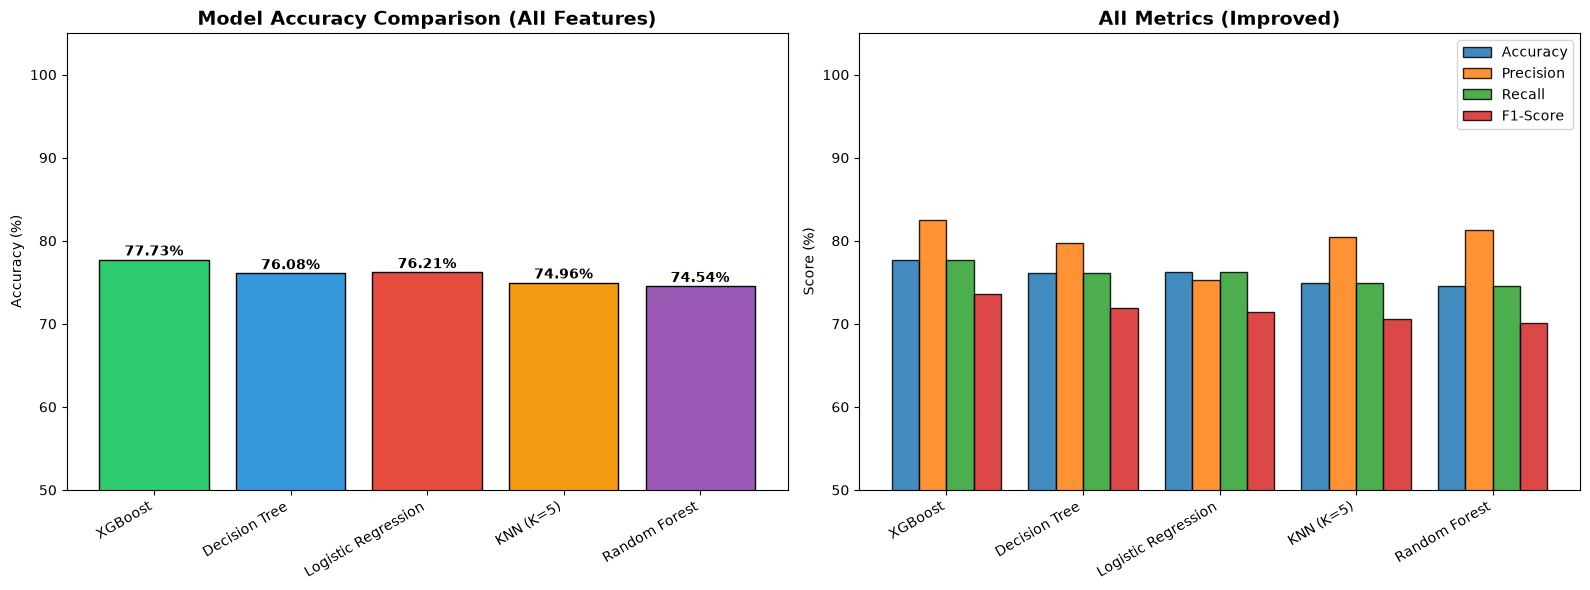

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

bars = axes[0].bar(range(len(r2)), r2['Accuracy'], color=colors, edgecolor='black')
axes[0].set_xticks(range(len(r2)))
axes[0].set_xticklabels(r2['Model'], rotation=30, ha='right')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison (All Features)', fontweight='bold', fontsize=14)
axes[0].set_ylim(50, 105)
for bar, val in zip(bars, r2['Accuracy']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val}%', ha='center', fontweight='bold')

x_pos = np.arange(len(r2))
width = 0.2
for i, m in enumerate(['Accuracy','Precision','Recall','F1-Score']):
    axes[1].bar(x_pos+i*width, r2[m], width, label=m, edgecolor='black', alpha=0.85)
axes[1].set_xticks(x_pos+width*1.5)
axes[1].set_xticklabels(r2['Model'], rotation=30, ha='right')
axes[1].set_ylabel('Score (%)')
axes[1].set_title('All Metrics (Improved)', fontweight='bold', fontsize=14)
axes[1].legend()
axes[1].set_ylim(50, 105)

plt.tight_layout()
plt.savefig('../reports/model_comparison_improved.png', dpi=150, bbox_inches='tight')
plt.show()

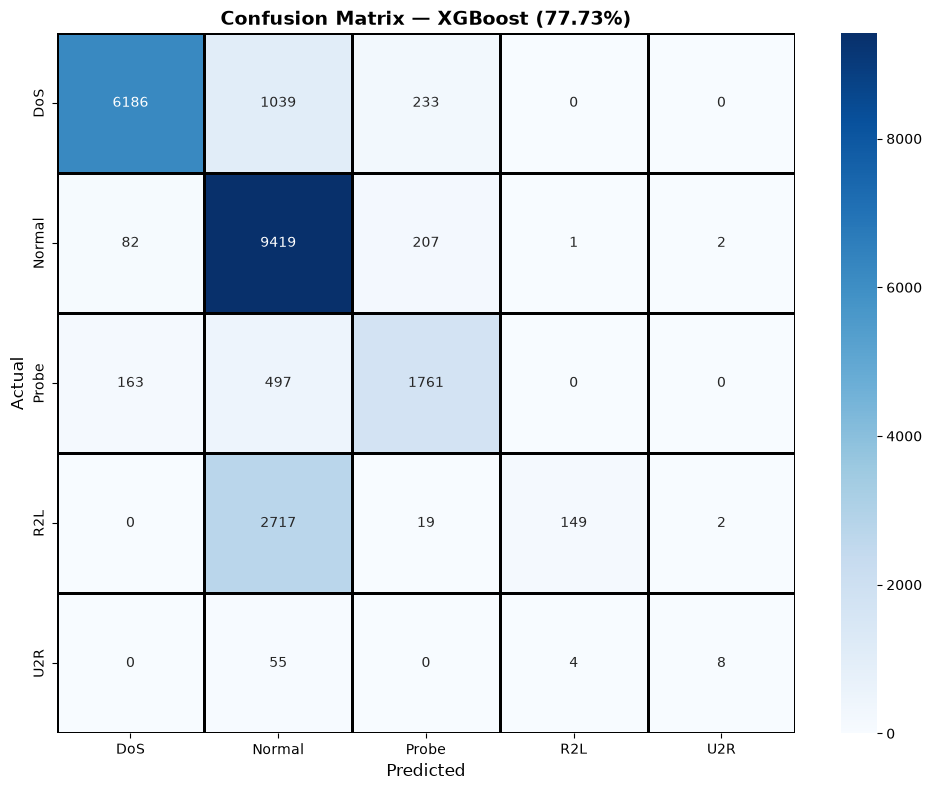

              precision    recall  f1-score   support

         DoS       0.96      0.83      0.89      7458
      Normal       0.69      0.97      0.80      9711
       Probe       0.79      0.73      0.76      2421
         R2L       0.97      0.05      0.10      2887
         U2R       0.67      0.12      0.20        67

    accuracy                           0.78     22544
   macro avg       0.82      0.54      0.55     22544
weighted avg       0.82      0.78      0.74     22544



In [14]:
best_name = r2.iloc[0]['Model']
y_pred_best = predictions[best_name]
cm = confusion_matrix(y_te, y_pred_best)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
            yticklabels=labels, ax=ax, linewidths=1, linecolor='black')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_name} ({r2.iloc[0]["Accuracy"]}%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_te, y_pred_best, target_names=labels))

In [15]:
import os
os.makedirs('../models', exist_ok=True)
print('✅ models folder created!')

✅ models folder created!


In [16]:
import joblib
import json

# Save the best model (XGBoost)
best_model_name = r2.iloc[0]['Model']
best_model = models[best_model_name]
joblib.dump(best_model, '../models/xgboost_model.pkl')
joblib.dump(sc, '../models/scaler.pkl')
joblib.dump(te, '../models/target_encoder.pkl')

# Save feature names
feature_names = list(X_tr.columns)
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

# Save results table
r2.to_csv('../models/results.csv', index=False)

print(f'✅ Saved: {best_model_name} model, scaler, encoder, features')
print(f'Features: {len(feature_names)}')

✅ Saved: XGBoost model, scaler, encoder, features
Features: 41
